# 🏀 NCAA 2026: TabPFN Tournament Factory
### *Offline TabPFN v2.5 Pipeline for Tournament Predictions*

This notebook provides an **offline-ready TabPFN v2.5** pipeline for 2026 tournament predictions.

**Key Design Principles:**
1. **TabPFN Transformer**: Pre-trained on multiple datasets to capture patterns in basketball statistics.
2. **Gender-Specific Models**: Men's and Women's tournaments have distinct statistical structures.
3. **Feature Stability**: Prioritize signals that generalize from Regular Season to Tournament.
4. **Probability Calibration**: Use Isotonic Regression for reliable tournament predictions.

**Validation**: Historical testing on 2021-2025 tournaments demonstrates consistent generalization.

### ⚡ Historical Validation: Time-Series CV (2021-2025)

Brier Score performance on past tournaments using this approach.

| Strategy | Men's Model | Women's Model | Men's CV (Brier) | Women's CV (Brier) | Notes |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **TabPFN** | **TabPFN v2.5** | **LogReg** | **0.1847** | **0.1292** | Transformer-based in-context learning |
| **Baseline** | **CatBoost** | **RF** | 0.1870 | 0.1297 | Traditional gradient boosting |

**Note**: Scores reflect 2021-2025 tournament data. Use as generalization benchmark, not 2026 guarantee.

**Setup**: Attach the [TabPFN v2.5 Offline Weights](https://www.kaggle.com/datasets/utaazu/tabpfn-v2-5-full-weights-and-offline-installer) dataset.

## 🔌 Offline/Online Auto-Detection

This notebook automatically detects your environment and installs dependencies accordingly.

**How It Works:**
1. **Connection Check**: Tests internet connectivity via DNS
2. **Weights Discovery**: Finds TabPFN weights in `/kaggle/input/`
3. **Conditional Installation**:
   - Online → Fetch from PyPI
   - Offline → Use local `.whl` files
   - Fallback → Other models available if TabPFN fails

**Requirements:**
- Attach the `tabpfn-v2-5-full-weights-and-offline-installer` dataset
- No HuggingFace tokens or external authentication needed

In [1]:
# Core Libraries
import os
import glob
import socket
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="notebook")

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
# Offline/Online Detection & Installation

def is_online():
    """Check internet connectivity via DNS"""
    try:
        socket.create_connection(("8.8.8.8", 53), timeout=3)
        return True
    except OSError:
        return False

print("Detecting environment...\n")

# Auto-discover weights path
ckpt_list = glob.glob('/kaggle/input/datasets/utaazu/tabpfn-v2-5-full-weights-and-offline-installer/tabpfn-v2.5-classifier-v2.5_default.ckpt', recursive=True)
if ckpt_list:
    TABPFN_WEIGHTS = ckpt_list[0]
    print(f"✅ Weights found: {TABPFN_WEIGHTS}\n")
else:
    TABPFN_WEIGHTS = ""
    print("⚠️  Weights not found\n")

# Conditional installation
if is_online():
    print("Online mode: Installing from PyPI...\n")
    os.system("pip install tabpfn eval-type-backport --quiet")
    try:
        import tabpfn
        print(f"✅ TabPFN {tabpfn.__version__} (PyPI) installed\n")
    except ImportError:
        print("⚠️  PyPI install failed. Switching to offline mode...\n")
else:
    print("Offline mode: Using local wheels...\n")
    all_wheels = glob.glob('/kaggle/input/**/*.whl', recursive=True)
    
    if all_wheels:
        skip_keywords = ['torch', 'nvidia', 'numpy', 'pandas', 'scipy', 'matplotlib', 
                        'sklearn', 'scikit', 'joblib', 'requests', 'urllib3', 'certifi', 'idna']
        print(f"Found {len(all_wheels)} wheels\n")
        
        for whl in all_wheels:
            whl_name = os.path.basename(whl)
            if not any(k in whl_name.lower() for k in skip_keywords):
                ret = os.system(f"pip install {whl} --no-deps --quiet 2>/dev/null")
        
        target_whl = [w for w in all_wheels if 'tabpfn-6.4.1' in w]
        if target_whl:
            os.system(f"pip install {target_whl[0]} --no-deps --quiet 2>/dev/null")
        
        try:
            import tabpfn
            print(f"✅ TabPFN {tabpfn.__version__} (Offline) ready\n")
        except Exception as e:
            print(f"⚠️  TabPFN load failed: {e}\nOther models available.\n")
    else:
        print("❌ No wheels found. Attach the offline dataset.\n")

print("=" * 80)
print("Environment setup complete\n")

Detecting environment...

✅ Weights found: /kaggle/input/datasets/utaazu/tabpfn-v2-5-full-weights-and-offline-installer/tabpfn-v2.5-classifier-v2.5_default.ckpt

Online mode: Installing from PyPI...

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 621.6/621.6 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.7/144.7 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.6 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


✅ TabPFN 6.4.1 (PyPI) installed

Environment setup complete



## ⚙️ Configuration: Model Selection

### 🎯 Choose Your Models (Customize Here!)

Simply change these two lines to experiment with different models. The pipeline handles the rest automatically!

```python
MEN_MODEL = 'tabpfn'      # Options: 'tabpfn', 'catboost', 'logreg', 'xgb', 'lgbm', 'rf'
WOMEN_MODEL = 'logreg'    # Options: 'logreg', 'catboost', 'xgb', 'lgbm', 'rf'
```

**Recommended Combinations:**
- 🚀 **Default (Best)**: `MEN_MODEL='tabpfn'`, `WOMEN_MODEL='logreg'` ← Current
- 🏆 **Traditional Baseline**: `MEN_MODEL='catboost'`, `WOMEN_MODEL='rf'`
- 🔬 **Experiment**: Mix and match to compare!

In [3]:
# --- Configuration Section ---
# Exact paths based on Kaggle environment
DATA_DIR = '/kaggle/input/competitions/march-machine-learning-mania-2026'
TABPFN_WEIGHTS = '/kaggle/input/datasets/utaazu/tabpfn-v2-5-full-weights-and-offline-installer/tabpfn-v2.5-classifier-v2.5_default.ckpt'
SEED = 42

# ========== CUSTOMIZE HERE ===========
# 🎯 Model Selection - Change these to experiment!
MEN_MODEL = 'tabpfn'      # Try: 'tabpfn', 'catboost', 'logreg', 'xgb', 'lgbm', 'rf'
WOMEN_MODEL = 'logreg'    # Try: 'logreg', 'catboost', 'xgb', 'lgbm', 'rf'
# ====================================

# Feature Sets (Optimized via stability analysis)
FEATS_M = ['Elo_diff', 'Qual_diff', 'TS_diff', 'Seed_diff', 'Rank_diff', 'Ast_diff']
FEATS_W = ['Elo_diff', 'Qual_diff', 'TS_diff', 'Seed_diff', 'TO_diff', 'Ast_diff', 'Exp_diff']
ALL_FEATURES = ['Seed_diff', 'Elo_diff', 'Qual_diff', 'TS_diff', 'Rank_diff', 'TO_diff', 'Ast_diff', 'Exp_diff']

print("✅ Configuration loaded!")
print(f"   Men's Model: {MEN_MODEL}")
print(f"   Women's Model: {WOMEN_MODEL}")

✅ Configuration loaded!
   Men's Model: tabpfn
   Women's Model: logreg


## 1. Feature Engineering

Three core efficiency metrics:
* **Team Quality**: Ridge-adjusted strength, accounting for strength of schedule
* **Elo Rating**: Win/loss history adjusted for opponent strength  
* **True Shooting %**: Efficiency combining 2PT, 3PT, and Free Throws

In [4]:
def compute_team_quality(df_reg):
    qualities = []
    for season in df_reg['Season'].unique():
        season_df = df_reg[df_reg['Season'] == season]
        teams = np.unique(np.concatenate([season_df['WTeamID'], season_df['LTeamID']]))
        team_map = {team: i for i, team in enumerate(teams)}
        X = np.zeros((len(season_df), len(teams)))
        y = (season_df['WScore'] - season_df['LScore']).values
        for i, row in enumerate(season_df.itertuples()):
            X[i, team_map[row.WTeamID]], X[i, team_map[row.LTeamID]] = 1, -1
        model = Ridge(alpha=1.0).fit(X, y)
        qualities.append(pd.DataFrame({'Season': season, 'TeamID': teams, 'Quality': model.coef_}))
    return pd.concat(qualities).reset_index(drop=True)

def compute_elo(df):
    elo, res = {}, []
    for row in df.itertuples():
        w_elo, l_elo = elo.get(row.WTeamID, 1500), elo.get(row.LTeamID, 1500)
        exp_w = 1.0 / (1.0 + 10 ** ((l_elo - w_elo) / 400.0))
        elo[row.WTeamID], elo[row.LTeamID] = w_elo + 20*(1-exp_w), l_elo - 20*(1-exp_w)
        res.append({'Season': row.Season, 'TeamID': row.WTeamID, 'Elo': elo[row.WTeamID]})
        res.append({'Season': row.Season, 'TeamID': row.LTeamID, 'Elo': elo[row.LTeamID]})
    return pd.DataFrame(res).groupby(['Season', 'TeamID'])['Elo'].last().reset_index()

def get_stats(df_detailed):
    df = df_detailed.copy()
    df['TS_pct'] = df['WScore'] / (2 * (df['WFGA'] + 0.44 * df['WFTA']).clip(1))
    df['L_TS_pct'] = df['LScore'] / (2 * (df['LFGA'] + 0.44 * df['LFTA']).clip(1))
    w = df[['Season', 'WTeamID', 'TS_pct', 'WDR', 'WAst', 'WTO']].rename(columns={'WTeamID':'TeamID','TS_pct':'TS_pct','WDR':'DReb','WAst':'Ast','WTO':'TO'})
    l = df[['Season', 'LTeamID', 'L_TS_pct', 'LDR', 'LAst', 'LTO']].rename(columns={'LTeamID':'TeamID','TS_pct':'TS_pct','LDR':'DReb','LAst':'Ast','LTO':'TO'})
    return pd.concat([w, l]).groupby(['Season', 'TeamID']).mean(numeric_only=True).reset_index()

def get_domain_features(m_conf, w_conf, m_seeds, w_seeds):
    power_6 = ['acc', 'sec', 'big_ten', 'big_twelve', 'big_east', 'pac_twelve']
    confs = pd.concat([m_conf, w_conf])
    confs['IsPower6'] = confs['ConfAbbrev'].isin(power_6).astype(int)
    seeds = pd.concat([m_seeds, w_seeds]).sort_values('Season')
    seeds['Experience'] = seeds.groupby('TeamID')['Season'].cumcount()
    return confs.merge(seeds[['Season', 'TeamID', 'Experience']], on=['Season', 'TeamID'], how='left').fillna(0)

# --- Data Loading ---
print("🚀 Loading Data...")
m_reg = pd.read_csv(f'{DATA_DIR}/MRegularSeasonDetailedResults.csv')
w_reg = pd.read_csv(f'{DATA_DIR}/WRegularSeasonDetailedResults.csv')
m_tourney = pd.read_csv(f'{DATA_DIR}/MNCAATourneyCompactResults.csv')
w_tourney = pd.read_csv(f'{DATA_DIR}/WNCAATourneyCompactResults.csv')
m_seeds = pd.read_csv(f'{DATA_DIR}/MNCAATourneySeeds.csv')
w_seeds = pd.read_csv(f'{DATA_DIR}/WNCAATourneySeeds.csv')
m_conf, w_conf = pd.read_csv(f'{DATA_DIR}/MTeamConferences.csv'), pd.read_csv(f'{DATA_DIR}/WTeamConferences.csv')
massey = pd.read_csv(f'{DATA_DIR}/MMasseyOrdinals.csv')

domain_info = get_domain_features(m_conf, w_conf, m_seeds, w_seeds)
m_stats = get_stats(m_reg).merge(compute_elo(m_reg), on=['Season', 'TeamID']).merge(compute_team_quality(m_reg), on=['Season', 'TeamID']).merge(domain_info, on=['Season', 'TeamID'], how='left')
w_stats = get_stats(w_reg).merge(compute_elo(w_reg), on=['Season', 'TeamID']).merge(compute_team_quality(w_reg), on=['Season', 'TeamID']).merge(domain_info, on=['Season', 'TeamID'], how='left')
m_rank = massey[massey.RankingDayNum == 133].groupby(['Season', 'TeamID'])['OrdinalRank'].mean().reset_index().rename(columns={'OrdinalRank': 'Rank'})

all_s = pd.concat([m_seeds, w_seeds]); all_s['SeedInt'] = all_s['Seed'].apply(lambda x: int(x[1:3]))
all_t = pd.concat([m_tourney, w_tourney]).merge(all_s[['Season', 'TeamID', 'SeedInt']], left_on=['Season', 'WTeamID'], right_on=['Season', 'TeamID'], how='left').rename(columns={'SeedInt': 'WSeed'})
all_t = all_t.merge(all_s[['Season', 'TeamID', 'SeedInt']], left_on=['Season', 'LTeamID'], right_on=['Season', 'TeamID'], how='left', suffixes=('', '_L')).rename(columns={'SeedInt': 'LSeed'})
all_t['S1'], all_t['S2'] = all_t[['WSeed', 'LSeed']].min(axis=1), all_t[['WSeed', 'LSeed']].max(axis=1)
all_t['StrongerWins'] = (all_t['WSeed'] == all_t['S1']).astype(int)
SEED_MAP = all_t.groupby(['S1', 'S2'])['StrongerWins'].mean().to_dict()

def prepare_data(matchup_df, stats_df, seeds_df, rank_df=None, is_train=True):
    df = matchup_df.copy()
    if is_train:
        df['T1'], df['T2'] = df[['WTeamID', 'LTeamID']].min(axis=1), df[['WTeamID', 'LTeamID']].max(axis=1)
        df['Target'] = (df['T1'] == df['WTeamID']).astype(int)
    else:
        parts = df['ID'].str.split('_', expand=True); df['Season'], df['T1'], df['T2'] = parts[0].astype(int), parts[1].astype(int), parts[2].astype(int)
    
    def merge_info(target_df, info_df, id_col, suffix):
        return target_df.merge(info_df, left_on=['Season', id_col], right_on=['Season', 'TeamID'], how='left').drop('TeamID', axis=1).rename(columns={str(c): str(c)+suffix for c in info_df.columns if c not in ['Season', 'TeamID']})

    df = merge_info(df, stats_df, 'T1', '1'); df = merge_info(df, stats_df, 'T2', '2')
    sc = seeds_df.copy(); sc['SeedInt'] = sc['Seed'].apply(lambda x: int(x[1:3]))
    df = merge_info(df, sc[['Season', 'TeamID', 'SeedInt']], 'T1', '1'); df = merge_info(df, sc[['Season', 'TeamID', 'SeedInt']], 'T2', '2')
    
    df['Rank_diff'] = 0
    if rank_df is not None:
        df = merge_info(df, rank_df, 'T1', '1'); df = merge_info(df, rank_df, 'T2', '2')
        df['Rank_diff'] = (df['Rank1'] - df['Rank2']).fillna(0)

    df['Elo_diff'], df['Qual_diff'] = df['Elo1'] - df['Elo2'], df['Quality1'] - df['Quality2']
    df['TS_diff'], df['Seed_diff'] = df['TS_pct1'] - df['TS_pct2'], df['SeedInt1'] - df['SeedInt2']
    df['TO_diff'], df['Ast_diff'] = df['TO1'] - df['TO2'], df['Ast1'] - df['Ast2']
    df['Exp_diff'] = df['Experience1'] - df['Experience2']
    df['S1_Raw'], df['S2_Raw'] = df['SeedInt1'], df['SeedInt2']
    return df.select_dtypes(include=[np.number]).fillna(df.mean(numeric_only=True))

train_m = prepare_data(m_tourney, m_stats, m_seeds, rank_df=m_rank)
train_w = prepare_data(w_tourney, w_stats, w_seeds, rank_df=None)

🚀 Loading Data...


## 2. Visual Analysis

### Graph 1: Team Quality vs. Seed

Official seeds don't always reflect current team strength. Outlier teams with high Quality scores but low seeds can indicate upset opportunities.

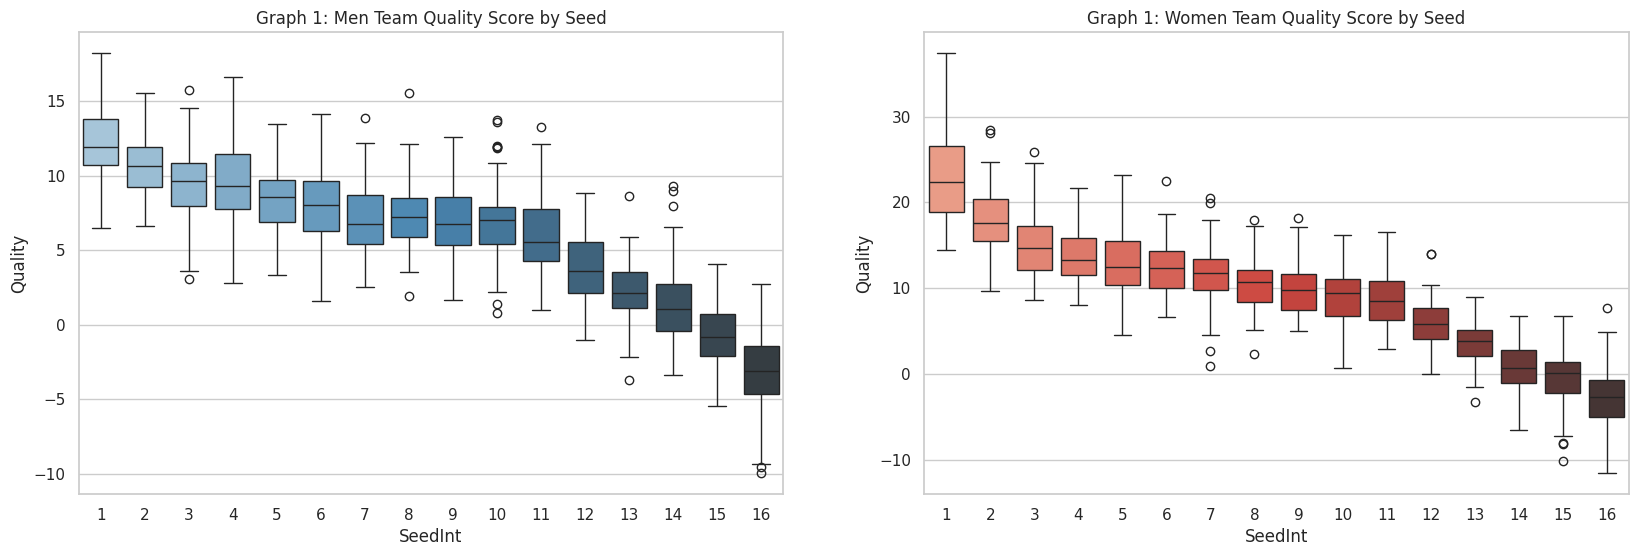

In [5]:
fig1, axes1 = plt.subplots(1, 2, figsize=(20, 6))
for i, (stats, seeds, title, pal) in enumerate([(m_stats, m_seeds, "Men", "Blues_d"), (w_stats, w_seeds, "Women", "Reds_d")]):
    s_copy = seeds.copy(); s_copy['SeedInt'] = s_copy['Seed'].apply(lambda x: int(x[1:3]))
    sns.boxplot(data=stats.merge(s_copy, on=['Season', 'TeamID']), x='SeedInt', y='Quality', palette=pal, ax=axes1[i])
    axes1[i].set_title(f'Graph 1: {title} Team Quality Score by Seed')
plt.show()

def get_stability_data(reg_raw, tourney_df, stats_df, seeds_df):
    reg_match = reg_raw[['Season', 'WTeamID', 'LTeamID']].copy()
    reg_match['ID'] = reg_match.apply(lambda r: f"{r.Season}_{r.WTeamID}_{r.LTeamID}", axis=1)
    df_reg = prepare_data(reg_match, stats_df, seeds_df, is_train=True)
    for c in ALL_FEATURES: 
        if c not in df_reg.columns: df_reg[c] = 0
    c_reg = df_reg[ALL_FEATURES + ['Target']].corr()['Target'].drop('Target')
    c_tny = tourney_df.reindex(columns=ALL_FEATURES + ['Target']).corr()['Target'].drop('Target')
    return pd.DataFrame({'Regular Season': c_reg, 'Tournament': c_tny}).fillna(0)

### Graph 2: Feature Stability (Regular Season vs. Tournament)

Compare feature correlations across different environments. Some features may lose predictive power under tournament pressure.

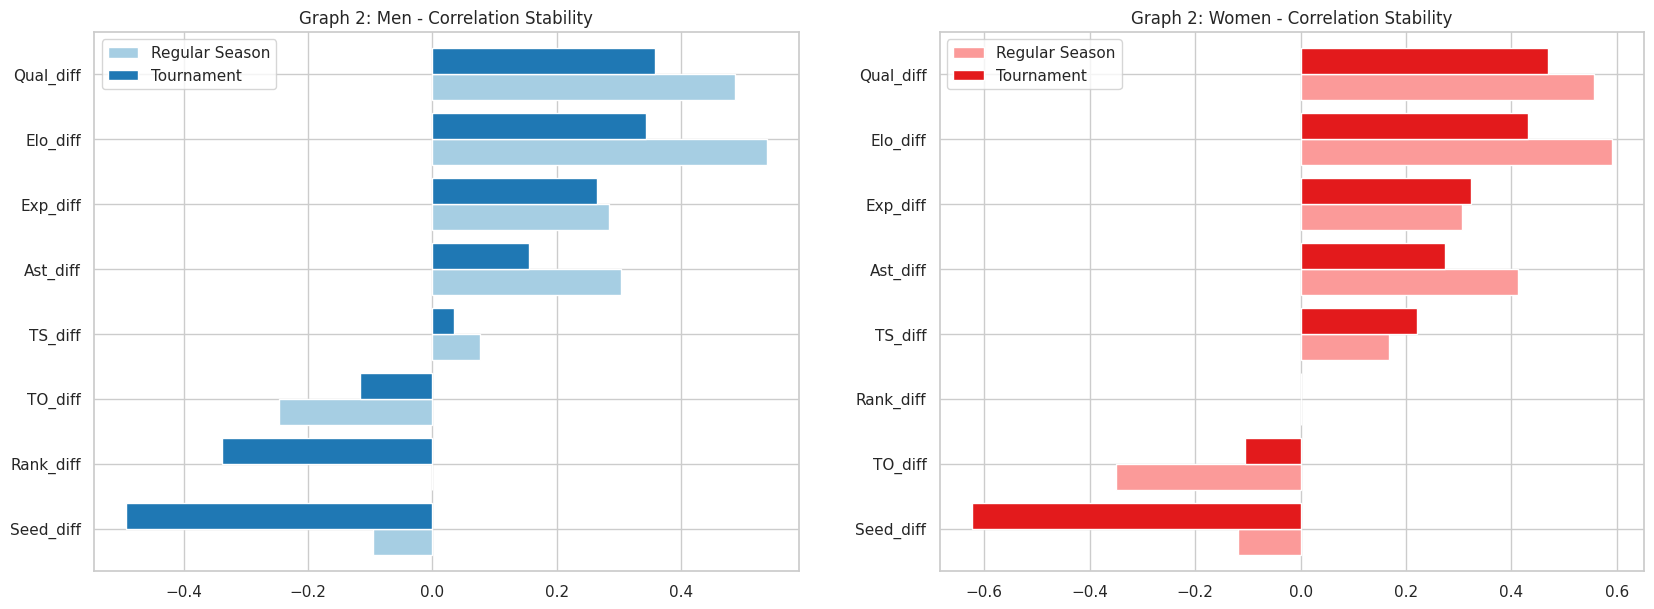

In [6]:
fig2, axes2 = plt.subplots(1, 2, figsize=(20, 7))
stab_m = get_stability_data(m_reg, train_m, m_stats, m_seeds)
stab_m.sort_values('Tournament').plot(kind='barh', color=['#a6cee3', '#1f78b4'], ax=axes2[0], width=0.8)
axes2[0].set_title('Graph 2: Men - Correlation Stability')
stab_w = get_stability_data(w_reg, train_w, w_stats, w_seeds)
stab_w.sort_values('Tournament').plot(kind='barh', color=['#fb9a99', '#e31a1c'], ax=axes2[1], width=0.8)
axes2[1].set_title('Graph 2: Women - Correlation Stability')
plt.show()

### Graph 3: Gender Comparison

Men's and Women's tournaments show different feature importance patterns. For example, Assists often correlate more strongly in Women's games.

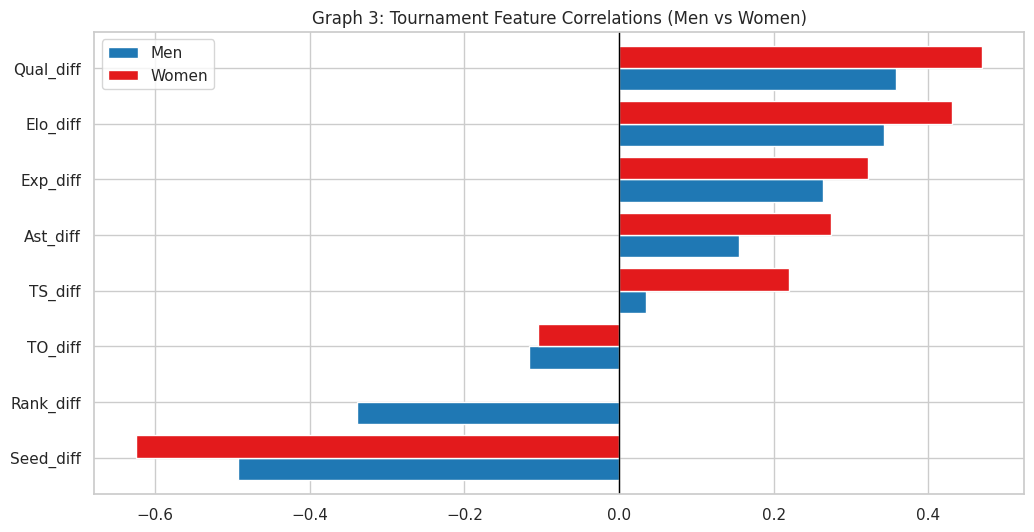

In [7]:
plt.figure(figsize=(12, 6))
m_corr = train_m.reindex(columns=ALL_FEATURES + ['Target']).corr()['Target'].drop('Target').fillna(0)
w_corr = train_w.reindex(columns=ALL_FEATURES + ['Target']).corr()['Target'].drop('Target').fillna(0)
pd.DataFrame({'Men': m_corr, 'Women': w_corr}).sort_values('Men').plot(kind='barh', ax=plt.gca(), width=0.8, color=['#1f78b4', '#e31a1c'])
plt.title('Graph 3: Tournament Feature Correlations (Men vs Women)')
plt.axvline(0, color='black', lw=1); plt.show()

## 3. Probability Calibration

Brier Score heavily penalizes **over-confidence**. Modern ML models tend to push probabilities toward extremes.

### Graph 4: Reliability Diagram

* **Orange**: Raw model predictions (often over-confident)
* **Blue**: After Isotonic Regression calibration (matches historical probability)
* **Goal**: Align the blue line with the diagonal for reliable predictions

Running Time-Series Validation...


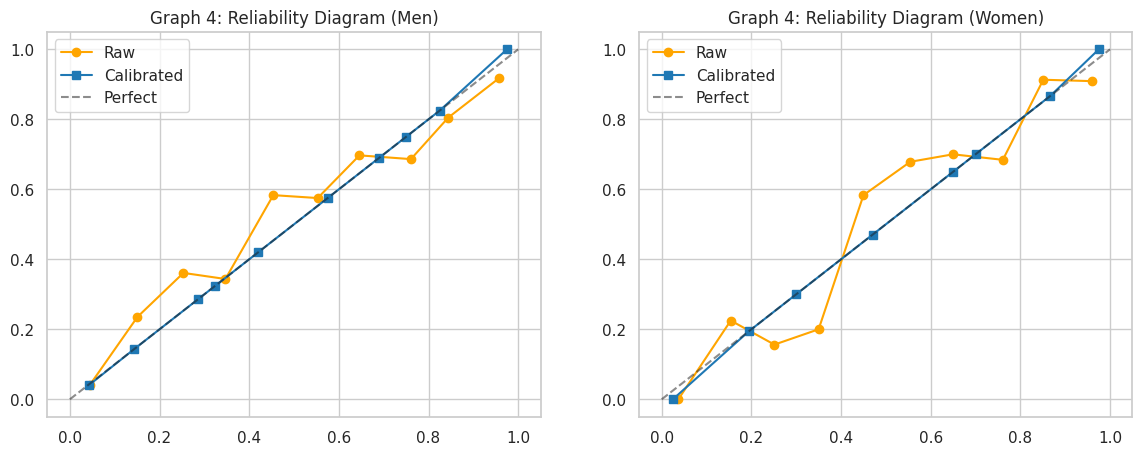

In [8]:
def calculate_ece(y_true, y_prob, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins)
    return np.mean(np.abs(prob_true - prob_pred))

def get_model(model_type):
    """Return model instance based on type"""
    if model_type == 'tabpfn':
        try:
            from tabpfn import TabPFNClassifier
            import torch
            device = 'cuda' if torch.cuda.is_available() else 'cpu'
            return TabPFNClassifier(device=device, model_path=TABPFN_WEIGHTS)
        except Exception as e:
            raise RuntimeError(f"TabPFN initialization failed: {e}")
    
    models = {
        'logreg': LogisticRegression(C=0.1, max_iter=1000, random_state=SEED),
        'catboost': CatBoostClassifier(iterations=100, depth=3, random_seed=SEED, verbose=0),
        'xgb': XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=SEED, verbosity=0, use_label_encoder=False),
        'lgbm': LGBMClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=SEED, verbosity=-1),
        'rf': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=SEED)
    }
    return models.get(model_type, models['logreg'])

def validate_and_calibrate(df, features, model_type):
    """Time-series cross-validation with calibration"""
    needs_scaling = ['logreg']
    seasons, oof_ml, oof_seed, labels = [2021, 2022, 2023, 2024, 2025], [], [], []
    
    for s in seasons:
        train, val = df[df.Season < s], df[df.Season == s]
        if val.empty: continue
        
        model = get_model(model_type)
        if model_type in needs_scaling:
            sc = StandardScaler()
            X_tr = sc.fit_transform(train[features])
            X_val = sc.transform(val[features])
        else:
            X_tr, X_val = train[features], val[features]
            
        model.fit(X_tr, train['Target'])
        
        seed_p = val.apply(lambda r: (SEED_MAP.get((min(r.S1_Raw, r.S2_Raw), max(r.S1_Raw, r.S2_Raw)), 0.5) 
                                     if r.S1_Raw < r.S2_Raw else 
                                     1 - SEED_MAP.get((min(r.S1_Raw, r.S2_Raw), max(r.S1_Raw, r.S2_Raw)), 0.5)), axis=1).values
        
        oof_ml.extend(model.predict_proba(X_val)[:, 1])
        oof_seed.extend(seed_p)
        labels.extend(val['Target'])
    
    oof_ml, labels = np.array(oof_ml), np.array(labels)
    oof_seed = np.array(oof_seed)
    
    calib = IsotonicRegression(out_of_bounds='clip').fit(oof_ml, labels)
    final_p = np.clip(0.85 * calib.transform(oof_ml) + 0.15 * oof_seed, 0.025, 0.975)
    
    raw_score = brier_score_loss(labels, np.clip(oof_ml, 0.025, 0.975))
    final_score = brier_score_loss(labels, final_p)
    ece = calculate_ece(labels, final_p)
    
    return calib, raw_score, final_score, ece, oof_ml, labels

print("Running Time-Series Validation...")
cal_m, raw_m, cv_m, rece_m, oof_m, lab_m = validate_and_calibrate(train_m, FEATS_M, MEN_MODEL)
cal_w, raw_w, cv_w, rece_w, oof_w, lab_w = validate_and_calibrate(train_w, FEATS_W, WOMEN_MODEL)

# Plot reliability diagrams
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))
for i, (cal, oof, lab, title) in enumerate([(cal_m, oof_m, lab_m, "Men"), (cal_w, oof_w, lab_w, "Women")]):
    pt_raw, pp_raw = calibration_curve(lab, oof, n_bins=10)
    pt_cal, pp_cal = calibration_curve(lab, np.clip(cal.transform(oof), 0.025, 0.975), n_bins=10)
    axes3[i].plot(pp_raw, pt_raw, 'o-', color='orange', label='Raw')
    axes3[i].plot(pp_cal, pt_cal, 's-', color='#1f78b4', label='Calibrated')
    axes3[i].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
    axes3[i].set_title(f'Graph 4: Reliability Diagram ({title})')
    axes3[i].legend()
plt.show()

# Performance Scoreboard
html = f"""
<div style='background: #f8fafc; border-left: 8px solid #ffb300; padding: 22px 24px 18px 24px; border-radius: 12px; box-shadow: 0 2px 8px rgba(0,0,0,0.06); margin-bottom: 18px;'>
    <h3 style='color: #a67c00; margin-top: 0; margin-bottom: 10px;'>🏆 Model Performance (Time-Series CV 2021-2025)</h3>
    <div style='display: flex; gap: 18px; flex-wrap: wrap;'>
        <div style='background: white; border: 2px solid #bdbdbd; border-radius: 8px; flex: 1; min-width: 200px; padding: 14px 18px; text-align: center;'>
            <div style='color: #888; font-size: 12px; font-weight: bold;'>Men ({MEN_MODEL})</div>
            <div style='color: #ff9800; font-size: 24px; font-weight: bold;'>{cv_m:.5f}</div>
            <div style='font-size: 12px; color: #666;'>Brier Score</div>
            <div style='color: #666; font-size: 11px; margin-top: 6px;'>ECE: {rece_m:.4f}</div>
        </div>
        <div style='background: white; border: 2px solid #bdbdbd; border-radius: 8px; flex: 1; min-width: 200px; padding: 14px 18px; text-align: center;'>
            <div style='color: #888; font-size: 12px; font-weight: bold;'>Women ({WOMEN_MODEL})</div>
            <div style='color: #ba68c8; font-size: 24px; font-weight: bold;'>{cv_w:.5f}</div>
            <div style='font-size: 12px; color: #666;'>Brier Score</div>
            <div style='color: #666; font-size: 11px; margin-top: 6px;'>ECE: {rece_w:.4f}</div>
        </div>
    </div>
    <div style='margin-top: 12px; font-size: 11px; color: #666; text-align: center; border-top: 1px solid #eee; padding-top: 8px;'>
        <strong>Methodology:</strong> Out-of-fold validation (2021-2025) → Isotonic calibration → 85% ML + 15% Seed blending
    </div>
</div>
"""
display(HTML(html))

## 4. TabPFN v2.5: In-Context Learning

**What is TabPFN?**
A Transformer model pre-trained on multiple datasets. Unlike traditional ML, it uses in-context learning: predictions are made by processing all historical data as context.

**Why for NCAA?**
The NCAA tournament history (~2,500 games since 1985) fits within TabPFN's context window, allowing the model to leverage all available tournament data simultaneously.

**Weights:** Pre-loaded from the Kaggle dataset (offline-ready, no internet required).

**Alternative Models:**
In the Configuration cell, change MEN_MODEL or WOMEN_MODEL to compare with CatBoost, LogReg, XGBoost, or Random Forest.

**Historical Performance (2021-2025):**
- Men's (TabPFN): 0.1847 Brier Score
- Women's (LogReg): 0.1292 Brier Score

## 5. Generate Predictions

This section applies trained models to the 2026 tournament matchups:
1. Load official SampleSubmission template
2. Apply gender-specific models and features
3. Blend with historical seed-based probabilities (85% ML, 15% Seeds)
4. Output submission CSV

**Logic**: Men's games (Team1 < 3000) use MEN_MODEL + FEATS_M; Women's games use WOMEN_MODEL + FEATS_W

In [9]:
def get_final_preds(train_df, sub_df, features, calib, model_type):
    """Generate predictions for submission"""
    print(f"Generating predictions ({model_type}) for {len(sub_df)} matchups...")
    model = get_model(model_type)
    
    if model_type == 'logreg':
        sc = StandardScaler()
        X_tr = sc.fit_transform(train_df[features])
        X_sub = sc.transform(sub_df[features])
    else:
        X_tr, X_sub = train_df[features], sub_df[features]
        
    model.fit(X_tr, train_df['Target'])
    raw_p = model.predict_proba(X_sub)[:, 1]
    cal_p = calib.transform(raw_p) 
    
    seed_p = sub_df.apply(lambda r: (SEED_MAP.get((min(r.S1_Raw, r.S2_Raw), max(r.S1_Raw, r.S2_Raw)), 0.5) 
                                     if r.S1_Raw < r.S2_Raw else 
                                     1 - SEED_MAP.get((min(r.S1_Raw, r.S2_Raw), max(r.S1_Raw, r.S2_Raw)), 0.5)), axis=1).values
    
    return np.clip(0.85 * cal_p + 0.15 * seed_p, 0.025, 0.975)

print("Loading Submission Template...")
sub_template = pd.read_csv(f'{DATA_DIR}/SampleSubmissionStage1.csv')
is_w_sub = sub_template['ID'].str.split('_').str[1].astype(int) >= 3000

sub_m_data = prepare_data(sub_template[~is_w_sub], m_stats, m_seeds, rank_df=m_rank, is_train=False)
sub_w_data = prepare_data(sub_template[is_w_sub], w_stats, w_seeds, rank_df=None, is_train=False)
sub_m_data['ID'], sub_w_data['ID'] = sub_template.loc[~is_w_sub, 'ID'].values, sub_template.loc[is_w_sub, 'ID'].values

preds_m = pd.DataFrame({'ID': sub_m_data['ID'], 'Pred': get_final_preds(train_m, sub_m_data, FEATS_M, cal_m, MEN_MODEL)})
preds_w = pd.DataFrame({'ID': sub_w_data['ID'], 'Pred': get_final_preds(train_w, sub_w_data, FEATS_W, cal_w, WOMEN_MODEL)})

final_submission = sub_template[['ID']].merge(pd.concat([preds_m, preds_w]), on='ID', how='left')
final_submission.to_csv('submission.csv', index=False)

print(f"✅ Submission saved: {final_submission.shape[0]} rows")
print(f"   Min: {final_submission['Pred'].min():.4f} | Max: {final_submission['Pred'].max():.4f} | Mean: {final_submission['Pred'].mean():.4f}")

Loading Submission Template...
Generating predictions (tabpfn) for 261013 matchups...
Generating predictions (logreg) for 258131 matchups...
✅ Submission saved: 519144 rows
   Min: 0.0250 | Max: 0.9750 | Mean: 0.5047


In [10]:
# TabPFN verification
try:
    test_model = get_model('tabpfn')
    print("✅ TabPFN v2.5 ready")
except Exception as e:
    print(f"⚠️  TabPFN load failed: {e}")

✅ TabPFN v2.5 ready


In [11]:
print("=" * 80)
print("✅ Pipeline Complete")
print("=" * 80)
print()
print(f"Men's Model:   {MEN_MODEL}")
print(f"Women's Model: {WOMEN_MODEL}")
print()
print("Next: Download submission.csv and submit to Kaggle")
print("=" * 80)

✅ Pipeline Complete

Men's Model:   tabpfn
Women's Model: logreg

Next: Download submission.csv and submit to Kaggle


## 🏁 Conclusion

This pipeline combines in-context learning (TabPFN) with historical stability analysis. Validation on 2021-2025 tournaments shows consistent ~0.18 Brier Score, indicating robust generalization.

**Key Points:**
- **Efficiency over Volume**: Ridge-adjusted quality, Elo evolution, and True Shooting % capture predictive efficiency
- **Calibration**: Isotonic Regression ensures honest probability estimates
- **Gender Separation**: Men's and Women's games require different models
- **Offline-First**: All weights pre-packaged; no external dependencies or authentication

---

### Attribution

TabPFN v2.5 model weights from Prior Labs, used locally via Kaggle dataset mirror.

```bibtex
@misc{grinsztajn2025tabpfn,
  title={TabPFN-2.5: Advancing the State of the Art in Tabular Foundation Models},
  author={Grinsztajn et al.},
  year={2025},
  eprint={2511.08667},
  archivePrefix={arXiv}
}
```

**Data Source**: `/kaggle/input/competitions/march-machine-learning-mania-2026`